1

In [14]:
import pandas as pd
from scipy import stats
from scipy.stats import norm
Uni = pd.read_csv("./Uni.csv", sep=";", encoding="cp1252", decimal=",")
Uni['B12'] = pd.to_numeric(Uni['B12'].astype(str).str.replace(',', '.', regex=False), errors='coerce')
print(Uni.head())

    TTG  Ferritin  VitD    B12  Kreatinin  Cholesterin Sex District   Age
0  3.32      23.9  59.2  226.0       74.2          6.7   f       PK  60.0
1  3.92      73.4  65.3  367.0       76.8          7.3   f       PK  45.0
2  1.93     220.0  61.9  177.0       58.5          7.6   f       PK  53.0
3  1.55      13.3  33.9  345.0       70.7          4.3   f       PK  44.0
4  2.08     129.0  44.0  370.0       90.1          6.0   f       PK  83.0


In [35]:
indicators = ['Ferritin', 'VitD', 'B12', 'Kreatinin', 'Cholesterin']
print(Uni[indicators].dtypes)

Ferritin       float64
VitD           float64
B12            float64
Kreatinin      float64
Cholesterin    float64
dtype: object


2 В таблице Uni удалите строки с пропущенными значениями (метод pd.DataFrame.dropna()).

In [15]:
df = Uni.dropna()

3 С помощью критерия Шапиро-Уилка (метод stats.shapiro) проверьте на нормальность распределения показатель TTG.

In [16]:
statistic, p_value = stats.shapiro(df['TTG'])

In [17]:
print(f"Shapiro-Wilk test statistic: {statistic}")
print(f"p-value: {p_value}")

Shapiro-Wilk test statistic: 0.43205420522479965
p-value: 8.740476001450042e-64


Анализ: Так как p-v <= 0.05, нулевая гипотеза отвергается. Распределение показателя TTG отличается от нормального.

4 С помощью критерия Колмогорова-Смирнова (stats.kstest) проверьте принадлежность показателя Age к нормальному виду распределения.

In [18]:
df_age = Uni['Age'].dropna()

In [19]:
age_mean = df_age.mean()
age_std = df_age.std()

Какой-то баг с  ndtr

In [20]:
statistic, p_value = stats.kstest(df_age, stats.norm.cdf, args=(age_mean, age_std))

In [21]:
print(f"Kolmogorov-Smirnov test statistic: {statistic}")
print(f"p-value: {p_value}")

Kolmogorov-Smirnov test statistic: 0.04498167975943379
p-value: 0.0002819200219058965


Так как p value < 0.05, то нулевую гипотезу отвергаем, распределение не является нормальынм

5 Для группы показателей Ferritin, VitD, B12, Kreatinin, Cholesterin проверку на нормальность проведите следующим образом:

In [32]:
print(Uni.isna().sum())

TTG            1
Ferritin       0
VitD           0
B12            1
Kreatinin      1
Cholesterin    1
Sex            2
District       0
Age            3
dtype: int64


In [33]:
Uni.dropna(inplace=True)
print(Uni.isna().sum())

TTG            0
Ferritin       0
VitD           0
B12            0
Kreatinin      0
Cholesterin    0
Sex            0
District       0
Age            0
dtype: int64


In [34]:
indicators = ['Ferritin', 'VitD', 'B12', 'Kreatinin', 'Cholesterin']
for indicator in indicators:
    stat, p_value = stats.shapiro(Uni[indicator])
    print(f'{indicator}: Shapiro-Wilk statistic={stat}, p-value={p_value}')

Ferritin: Shapiro-Wilk statistic=0.6363112786396022, p-value=9.982329163331701e-56
VitD: Shapiro-Wilk statistic=0.8916388703664883, p-value=1.1596355536172078e-36
B12: Shapiro-Wilk statistic=0.6861488059474579, p-value=3.470388323666401e-53
Kreatinin: Shapiro-Wilk statistic=0.8827783407114639, p-value=8.95251920514843e-38
Cholesterin: Shapiro-Wilk statistic=0.9752747022356414, p-value=5.623754926632733e-19


Для всех пяти показателей p value < 0,05, поэтому нулевая гипотеза о нормальном распределении отвергается

6 Постройте гистограммы с наложением кривой плотности распределения для количественных показателей.

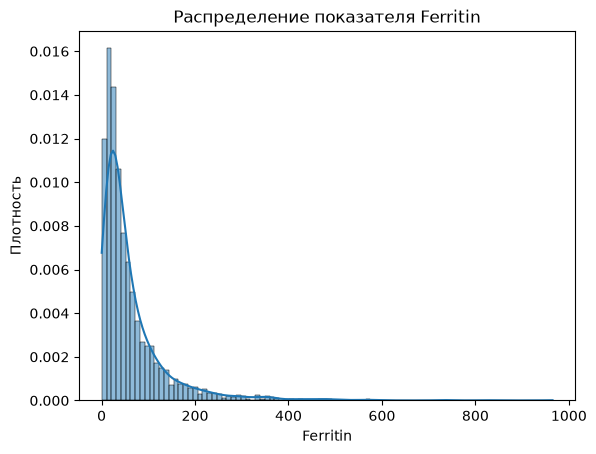

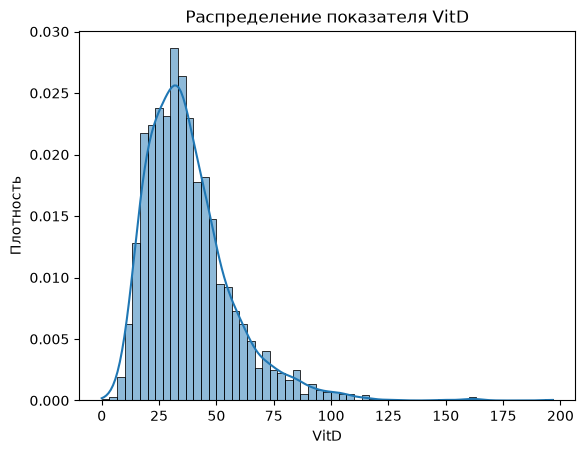

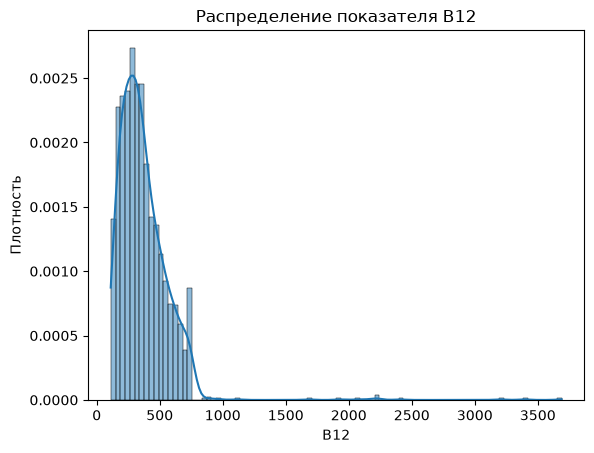

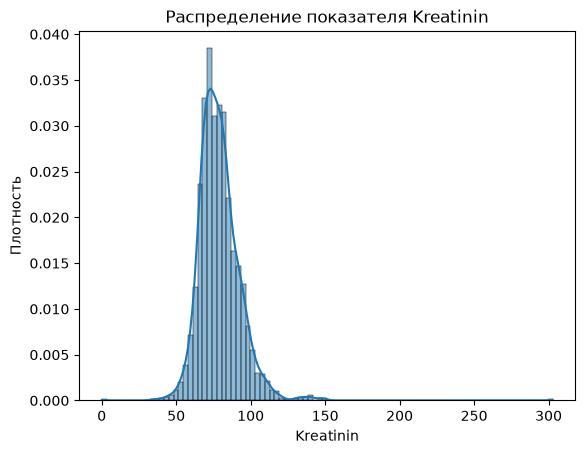

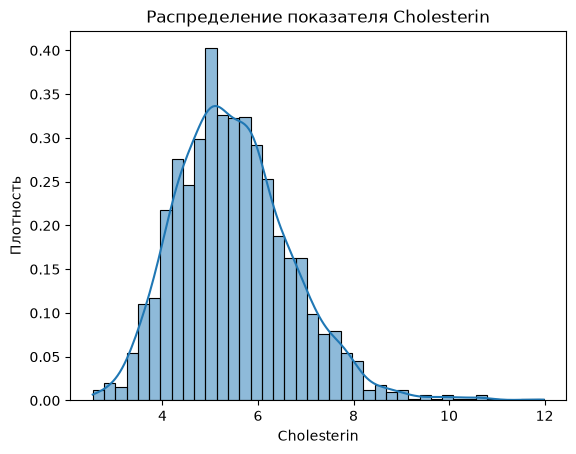

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
for indicator in indicators:
    data = Uni[indicator]

    sns.histplot(data,kde=True, stat='density')

    plt.title(f'Распределение показателя {indicator}')
    plt.xlabel(indicator)
    plt.ylabel('Плотность')
    plt.show()

7 Рассчитайте медианные значения и соответствующие доверительные интервалы [Q1,Q3] для всех количественных показателей по всей выборке.

In [42]:
df.describe()

,TTG,Ferritin,VitD,B12,Kreatinin,Cholesterin,Age
count,2181.000000,2181.000000,2181.000000,2181.000000,2181.000000,2181.000000,2181.000000
mean,2.298941,63.396731,37.952866,369.041265,78.994214,5.498372,48.818432
std,2.607085,81.365075,19.049316,221.217619,14.098580,1.212640,14.643533
min,0.010000,0.300000,0.000000,111.000000,0.000000,2.540000,6.000000
25%,1.240000,18.000000,24.700000,234.000000,70.210000,4.650000,38.000000
50%,1.830000,36.700000,34.500000,330.000000,77.300000,5.400000,48.000000
75%,2.630000,74.800000,46.400000,462.000000,85.700000,6.200000,59.000000
max,53.300000,965.200000,196.600000,3689.000000,302.700000,11.980000,90.000000


8 Рассчитайте медианные значения количественных показателей по категориям показателей Sex и District (по двум факторам одновременно).

In [43]:
medians = df.groupby(['Sex', 'District'])[indicators].median()
print(medians)

                Ferritin   VitD    B12  Kreatinin  Cholesterin
Sex District                                                  
f   Irkutsk        29.05  27.45  316.5     74.035         5.14
    Khabarovsk     26.20  29.60  342.0     74.000         5.51
    PK             35.90  42.60  355.0     75.700         5.50
    Sakhalin       55.50  37.10  348.0     84.200         5.70
m   Irkutsk        81.15  25.25  271.0     90.735         5.16
    Khabarovsk     45.20  30.80  300.0     90.000         5.29
    PK            108.20  45.40  315.0     93.000         5.50
    Sakhalin      134.10  39.60  350.0    109.000         5.00


9 Постройте столбиковые диаграммы для количественных показателей по категориям показателей Sex и District (по двум факторам одновременно).

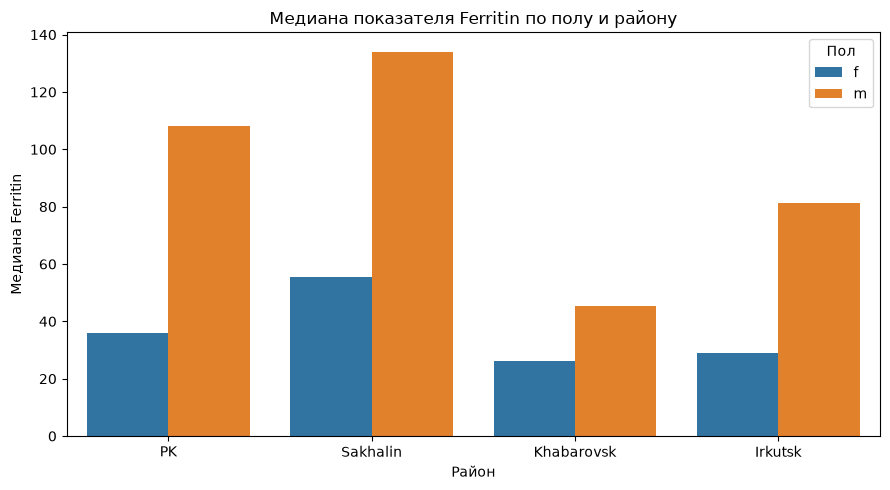

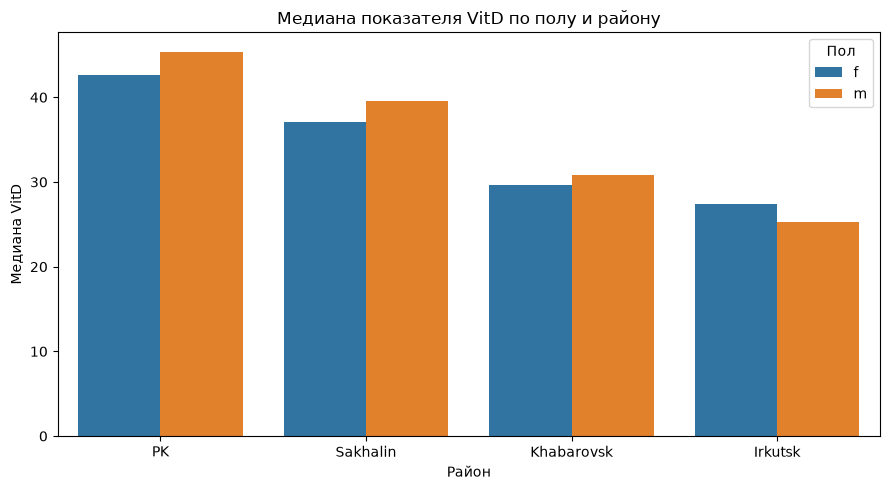

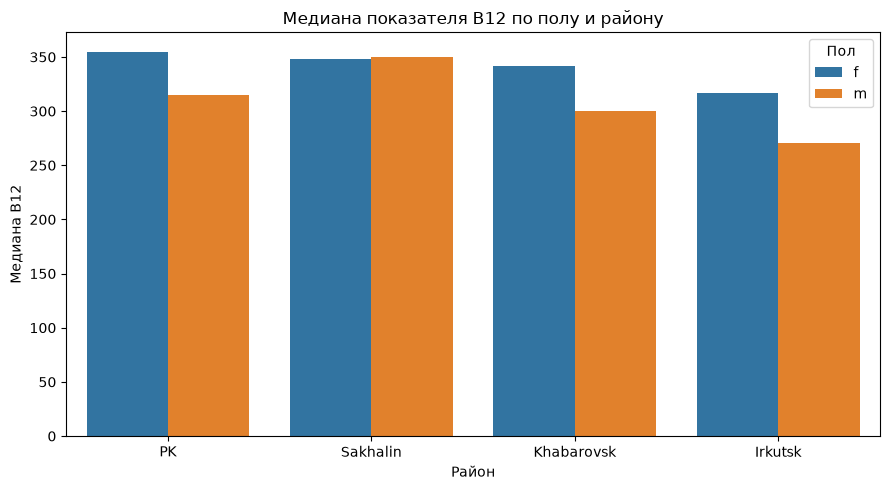

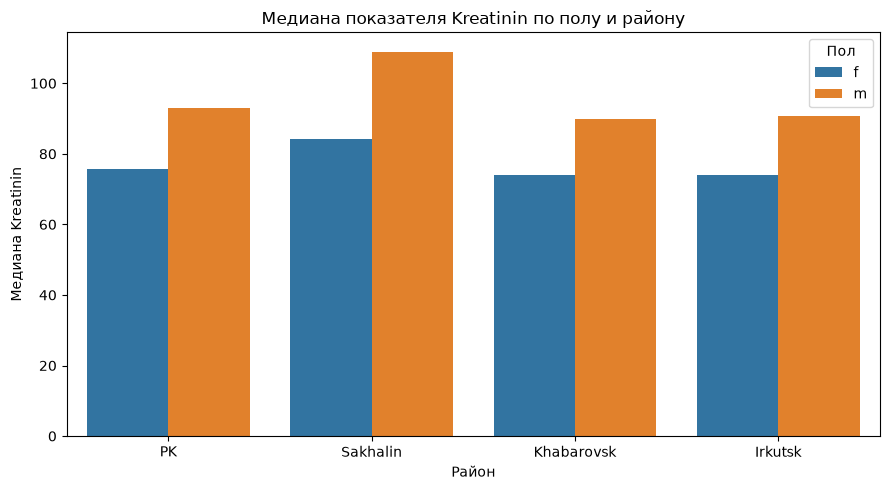

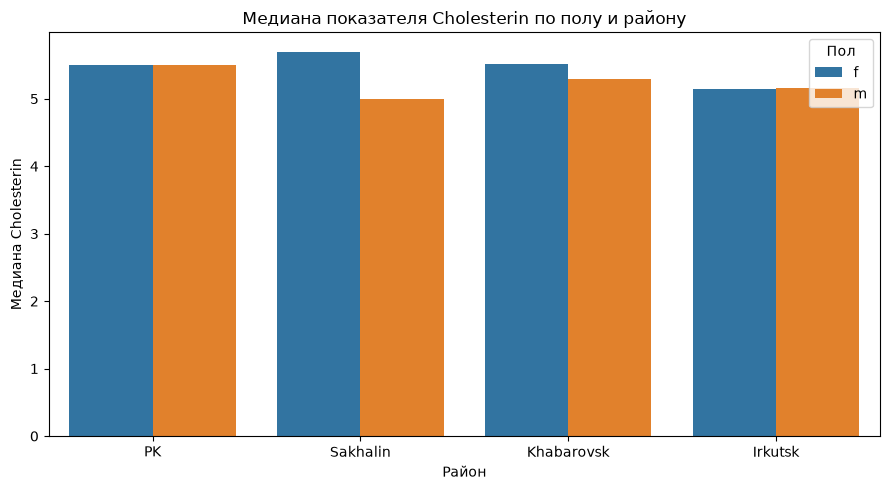

In [48]:
import numpy as np
for indicator in indicators:
    plt.figure(figsize=(9, 5))

    sns.barplot(
        data=df,
        x='District',
        y=indicator,
        hue='Sex',
        estimator=np.median,
        errorbar=None
    )

    plt.title(f'Медиана показателя {indicator} по полу и району')
    plt.xlabel('Район')
    plt.ylabel(f'Медиана {indicator}')
    plt.legend(title='Пол')
    plt.tight_layout()
    plt.show()

In [49]:
bins = [0, 18, 45, 60, 75, 90, 150]
labels = ['до 18', 'молодость (18-44)', 'средний возраст (45-59)', 'пожилой человек (60-74)', 'старческий возраст (75-90)', 'долгожитель (90+)']
Uni['Age_category'] = pd.cut(Uni['Age'], bins=bins, labels=labels, right=False) 

11 Рассчитайте количество человек в каждой возрастной группе, сколько среди них мужчин и женщин. Визуализируйте результаты.

In [54]:
print(Uni['Age_category'].value_counts())

Age_category
молодость (18-44)             867
средний возраст (45-59)       729
пожилой человек (60-74)       449
старческий возраст (75-90)     94
до 18                          41
долгожитель (90+)               1
Name: count, dtype: int64


In [57]:
age_sex = pd.crosstab(Uni['Age_category'], Uni['Sex'])
print(age_sex)


Sex                           f    m
Age_category                        
до 18                        18   23
молодость (18-44)           679  188
средний возраст (45-59)     588  141
пожилой человек (60-74)     368   81
старческий возраст (75-90)   79   15
долгожитель (90+)             0    1


<Axes: xlabel='Age_category'>

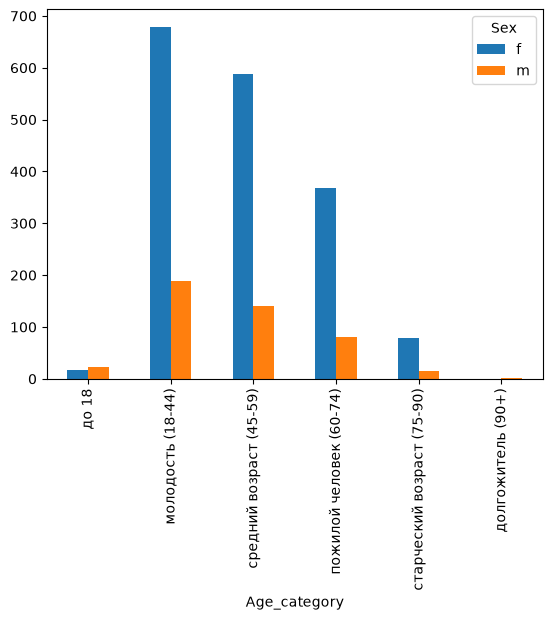

In [60]:
age_sex.plot(kind='bar')

12 Создайте вектор со средними значениями продолжительности жизни по республикам Кавказа (включая Адыгею):

In [61]:
rosstat = [79.42, 75.83, 74.16, 73.91, 73.82, 73.06, 72.01]

13 Проверьте вектор на нормальность распределения.

In [62]:
statistic, p_value = stats.shapiro(rosstat)
print(f"Shapiro-Wilk test statistic: {statistic}")
print(f"p-value: {p_value}")

Shapiro-Wilk test statistic: 0.8631797469953205
p-value: 0.16161402682644704


p-value > 0.05, следовательно закон распределения отличается от нормального

14 Запустите одновыборочный t-тест, указав в параметре mu - среднее значение ожидаемого возраста жизни по России равное 70.93. Опишите полученные результаты.

In [63]:
mu = 70.93
statistic, p_value = stats.ttest_1samp(rosstat, popmean=mu)
print(f"t-test statistic: {statistic}")
print(f"p-value: {p_value}")

t-test statistic: 4.015938757472049
p-value: 0.006991029459269378


p value < 0.05, следовательно разница меж средним и Mu статистически значима. Тобишь средняя продолжительность жизни в по республикам кавказа отличается. 
Выборка маловата для жестких выводов, 7 штук всего

15 Нужно узнать, отличается ли урожайность картофеля на севере и на юге региона. Для этого, собрали данные с 40 фермерских хозяйств: 20 из которых располагались на севере и сформировали выборку "North", а остальные 20 - на юге, сформировав выборку "South".

In [64]:
North = [122, 150, 136, 129, 169, 158, 132, 162, 143, 179, 139, 193, 155, 160, 165, 149, 173, 173, 141, 166]
South = [170, 163, 178, 150, 166, 142, 157, 149, 151, 164, 163, 161, 159, 139, 180, 155, 144, 139, 151, 160]

16 Проверьте данные на нормальность распределения.Я

In [67]:
statistic_n, pv_n = stats.shapiro(North)
statistic_s, pv_s = stats.shapiro(South)

print(f'North: Shapiro-Wilk statistic={statistic_n}, p-value={pv_n}')
print(f'South: Shapiro-Wilk statistic={statistic_s}, p-value={pv_s}')

North: Shapiro-Wilk statistic=0.9856796634531801, p-value=0.9853814949471612
South: Shapiro-Wilk statistic=0.9663329697062951, p-value=0.6763434738981118


У обоих векторов p value >= 0.05, значит нулевая гипотеза не отвеграется

17 Проведите двувыборочный t-тест для сравнения двух независимых выборок North и South.

In [68]:
stat, p_value = stats.ttest_ind(North, South, equal_var=False)

print(f'Средняя урожайность North: {np.mean(North)}')
print(f'Средняя урожайность South: {np.mean(South)}')
print(f't-test statistic: {stat}')
print(f'p-value: {p_value}')

Средняя урожайность North: 154.7
Средняя урожайность South: 157.05
t-test statistic: -0.48076967345703325
p-value: 0.6339369989648874


p value >= 0.05 
статистически значемых различий нет в урожайности картошки на юге и западе. Нельзя точно сказать, что урожайность отличается

18 Объедините выборки в таблицу и постройте диаграмму размаха.

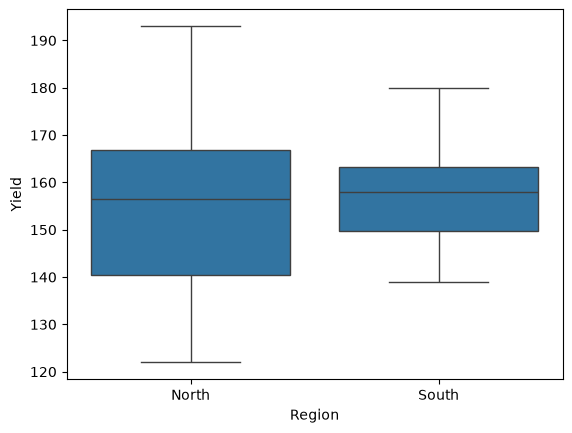

In [69]:
kartofka = pd.DataFrame({'Yield': North +South,'Region': ['North'] * len(North) + ['South'] * len(South)})
sns.boxplot(data=kartofka, x='Region', y='Yield')
plt.show()

Визуально на плоте разброс на севере выше, но медианы и средние схожи. На юге растить картошку стабильнее

19 Для проверки когнитивных способностей группе людей были выданы логические задания до и после прохождения курса обучения. Нужно с помощью критерия Стьюдента для зависимых выборок проверить значимость различий результатов (время выполнения заданий).

In [70]:
do = [25, 23, 28, 29, 35, 31, 24, 24, 38, 26, 20]
posle = [22, 25, 23, 22, 30, 27, 20, 19, 32, 25, 19]

In [74]:
stat, p_value = stats.ttest_rel(do, posle)

print(f'Paired t-test statistic: {stat}')
print(f'p-value: {p_value}')

Paired t-test statistic: 4.4854261357253025
p-value: 0.0011691592106779297


p value < 0.05, значит различия статистически значимы
Так как t-test > 0, значит до курса лог задания занимали больше времени.